In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

IMAGE_DIR: /kaggle/input/datasets/hocop1/kitti-odometry/sequences/00/image_2
POSE_PATH: /kaggle/input/datasets/hocop1/kitti-odometry/poses/00.txt
Image folder exists: True
Pose file exists: True
Total images used: 250

Generating depth maps...
Device: cuda


Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

Saved depth: 0
Saved depth: 20
Saved depth: 40
Saved depth: 60
Saved depth: 80
Saved depth: 100
Saved depth: 120
Saved depth: 140
Saved depth: 160
Saved depth: 180
Saved depth: 200
Saved depth: 220
Saved depth: 240

Generating uncertainty maps...
Saved uncertainty: 0000
Saved uncertainty: 0020
Saved uncertainty: 0040
Saved uncertainty: 0060
Saved uncertainty: 0080
Saved uncertainty: 0100
Saved uncertainty: 0120
Saved uncertainty: 0140
Saved uncertainty: 0160
Saved uncertainty: 0180
Saved uncertainty: 0200
Saved uncertainty: 0220
Saved uncertainty: 0240

Running baseline visual odometry...
baseline: processed frame 0
baseline: processed frame 25
baseline: processed frame 50
baseline: processed frame 75
baseline: processed frame 100
baseline: processed frame 125
baseline: processed frame 150
baseline: processed frame 175
baseline: processed frame 200
baseline: processed frame 225


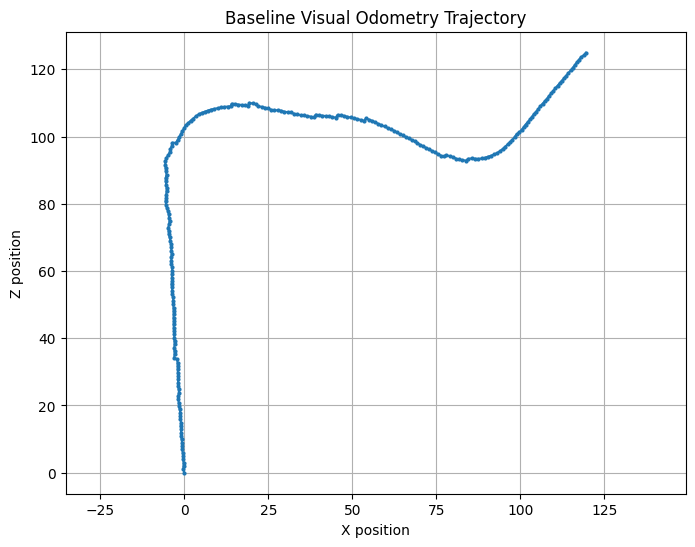


Running filtered visual odometry...
filtered: processed frame 0
filtered: processed frame 25
filtered: processed frame 50
filtered: processed frame 75
filtered: processed frame 100
filtered: processed frame 125
filtered: processed frame 150
filtered: processed frame 175
filtered: processed frame 200
filtered: processed frame 225


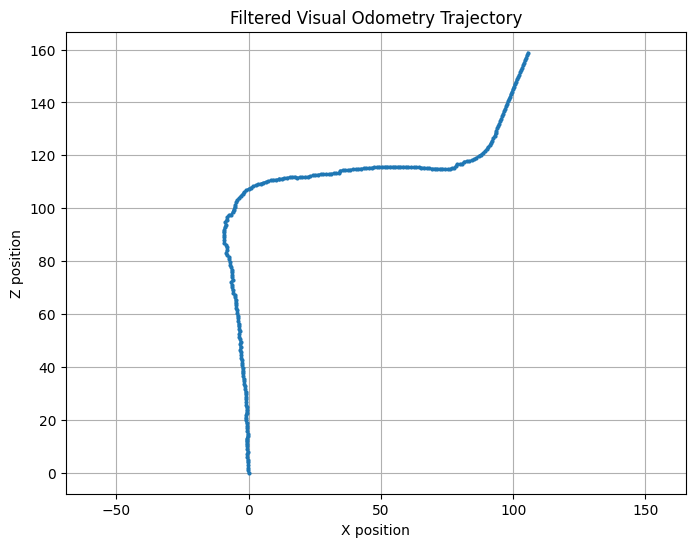


Evaluating results...

===== RESULTS =====
Baseline ATE: 13.54803446612973
Filtered ATE: 8.145818778090401
Baseline RPE: 0.27504493407622377
Filtered RPE: 0.21236967091717396
ATE Improvement: 39.87%


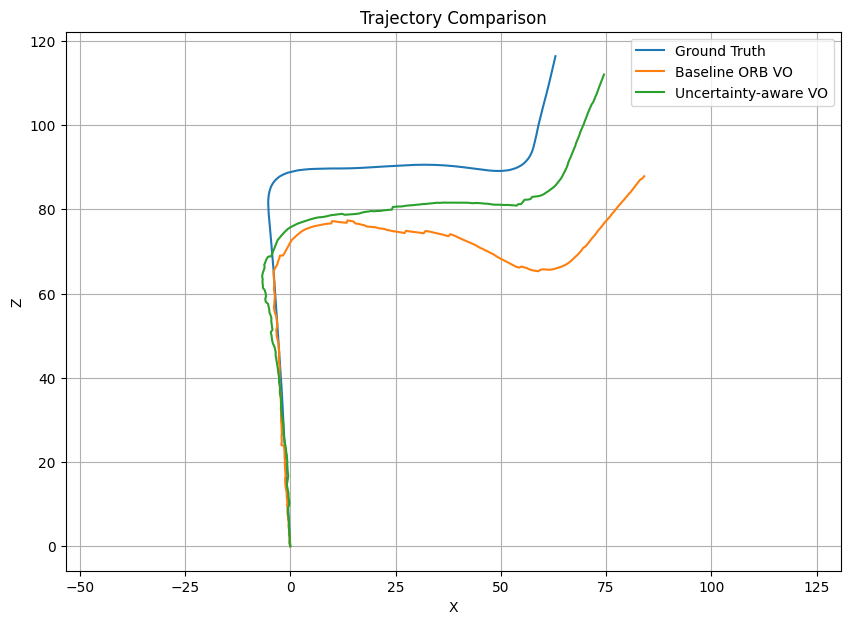


Creating dashboard...


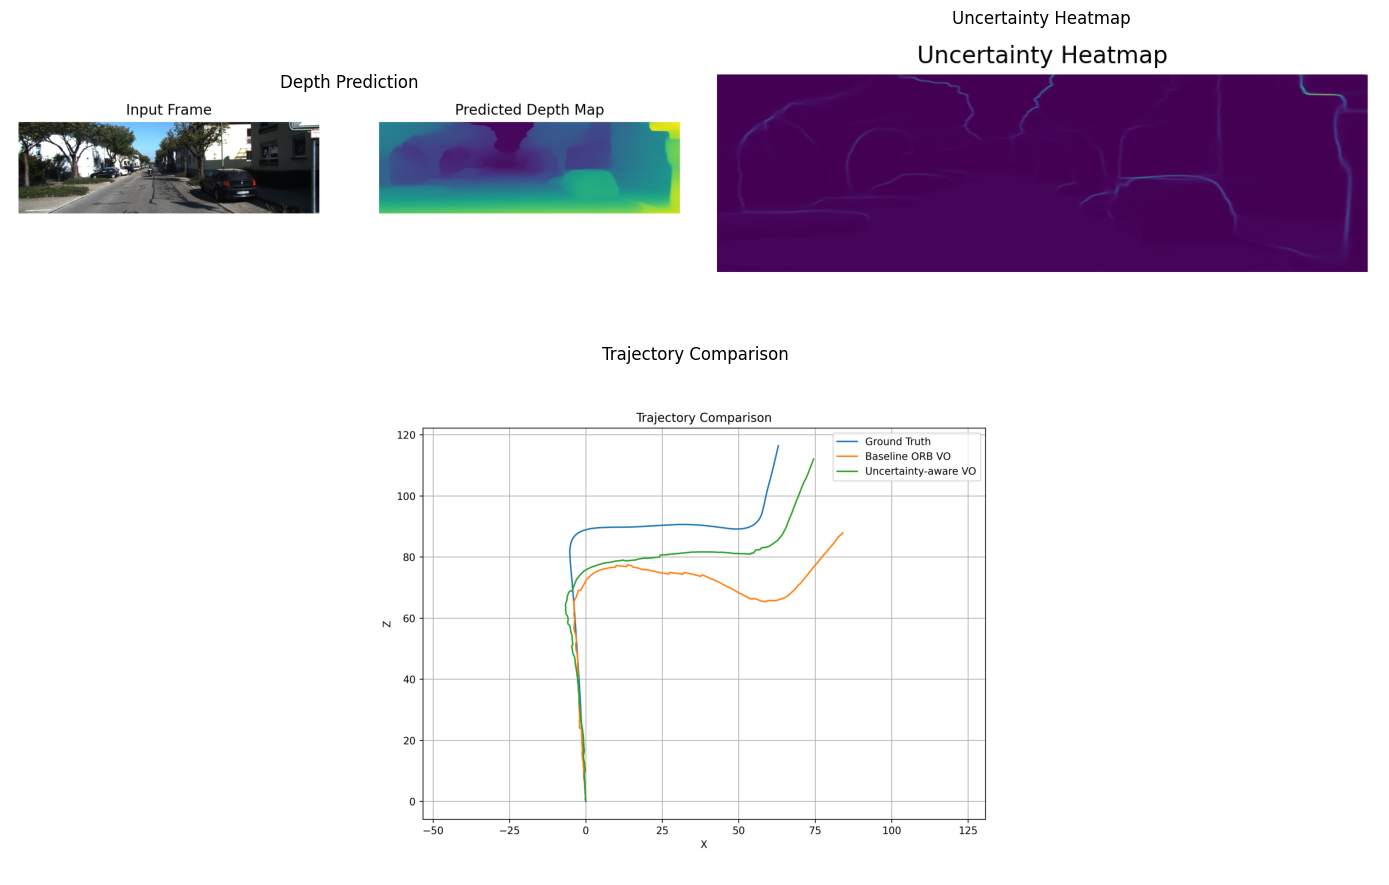


DONE.
Outputs saved in: /kaggle/working/outputs

Generated files:
/kaggle/working/outputs -> 3 files
/kaggle/working/outputs/uncertainty -> 26 files
/kaggle/working/outputs/masks -> 13 files
/kaggle/working/outputs/matches -> 26 files
/kaggle/working/outputs/trajectories -> 4 files
/kaggle/working/outputs/depth -> 26 files


In [6]:


!pip install transformers timm -q

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import mean_squared_error
from transformers import DPTImageProcessor, DPTForDepthEstimation
from IPython.display import Image as IPImage, display


# ============================================================
# 1. DATASET PATHS
# ============================================================

IMAGE_DIR = "/kaggle/input/datasets/hocop1/kitti-odometry/sequences/00/image_2"
POSE_PATH = "/kaggle/input/datasets/hocop1/kitti-odometry/poses/00.txt"

print("IMAGE_DIR:", IMAGE_DIR)
print("POSE_PATH:", POSE_PATH)
print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("Pose file exists:", os.path.exists(POSE_PATH))

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError("Image folder not found. Check IMAGE_DIR.")

if not os.path.exists(POSE_PATH):
    raise FileNotFoundError("Pose file not found. Check POSE_PATH.")


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = "/kaggle/working/outputs"
DEPTH_DIR = f"{OUTPUT_DIR}/depth"
UNCERTAINTY_DIR = f"{OUTPUT_DIR}/uncertainty"
MASK_DIR = f"{OUTPUT_DIR}/masks"
MATCH_DIR = f"{OUTPUT_DIR}/matches"
TRAJ_DIR = f"{OUTPUT_DIR}/trajectories"

for folder in [
    OUTPUT_DIR,
    DEPTH_DIR,
    UNCERTAINTY_DIR,
    MASK_DIR,
    MATCH_DIR,
    TRAJ_DIR
]:
    os.makedirs(folder, exist_ok=True)


# ============================================================
# 3. CAMERA MATRIX FOR KITTI SEQUENCE 00
# ============================================================

K = np.array([
    [718.856, 0, 607.1928],
    [0, 718.856, 185.2157],
    [0, 0, 1]
])


# ============================================================
# 4. LOAD IMAGE PATHS
# ============================================================

image_paths = sorted([
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png") or f.endswith(".jpg")
])

MAX_FRAMES = 250
image_paths = image_paths[:MAX_FRAMES]

print("Total images used:", len(image_paths))

if len(image_paths) < 2:
    raise ValueError("Need at least 2 images.")


# ============================================================
# 5. DEPTH ESTIMATION
# ============================================================

def generate_depth_maps(image_paths, every=20):
    print("\nGenerating depth maps...")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    processor = DPTImageProcessor.from_pretrained("Intel/dpt-hybrid-midas")
    model = DPTForDepthEstimation.from_pretrained("Intel/dpt-hybrid-midas")
    model.to(device)
    model.eval()

    for idx, img_path in enumerate(image_paths):
        if idx % every != 0:
            continue

        image = Image.open(img_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            predicted_depth = outputs.predicted_depth

        depth = torch.nn.functional.interpolate(
            predicted_depth.unsqueeze(1),
            size=image.size[::-1],
            mode="bicubic",
            align_corners=False
        )

        depth = depth.squeeze().cpu().numpy()
        depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

        np.save(f"{DEPTH_DIR}/depth_{idx:04d}.npy", depth)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Input Frame")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(depth)
        plt.title("Predicted Depth Map")
        plt.axis("off")

        plt.savefig(
            f"{DEPTH_DIR}/depth_{idx:04d}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.close()

        print("Saved depth:", idx)


# ============================================================
# 6. UNCERTAINTY MAP GENERATION
# ============================================================

def generate_uncertainty_maps():
    print("\nGenerating uncertainty maps...")

    depth_files = sorted([
        f for f in os.listdir(DEPTH_DIR)
        if f.endswith(".npy")
    ])

    for file in depth_files:
        idx = file.split("_")[1].replace(".npy", "")

        depth = np.load(os.path.join(DEPTH_DIR, file))
        depth_tensor = torch.tensor(depth).float()

        grad_x = torch.abs(depth_tensor[:, 1:] - depth_tensor[:, :-1])
        grad_y = torch.abs(depth_tensor[1:, :] - depth_tensor[:-1, :])

        grad_x = torch.nn.functional.pad(grad_x, (0, 1, 0, 0))
        grad_y = torch.nn.functional.pad(grad_y, (0, 0, 0, 1))

        uncertainty = grad_x + grad_y

        uncertainty = (
            uncertainty - uncertainty.min()
        ) / (
            uncertainty.max() - uncertainty.min() + 1e-8
        )

        uncertainty = uncertainty.numpy()

        np.save(f"{UNCERTAINTY_DIR}/uncertainty_{idx}.npy", uncertainty)

        plt.figure(figsize=(6, 5))
        plt.imshow(uncertainty)
        plt.title("Uncertainty Heatmap")
        plt.axis("off")

        plt.savefig(
            f"{UNCERTAINTY_DIR}/uncertainty_{idx}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.close()

        print("Saved uncertainty:", idx)


# ============================================================
# 7. VISUAL ODOMETRY
# ============================================================

def run_visual_odometry(image_paths, mode="baseline", threshold=0.4):
    print(f"\nRunning {mode} visual odometry...")

    orb = cv2.ORB_create(nfeatures=3000)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    R_total = np.eye(3)
    t_total = np.zeros((3, 1))

    trajectory = [(0, 0)]

    for i in range(len(image_paths) - 1):

        img1 = cv2.imread(image_paths[i], cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(image_paths[i + 1], cv2.IMREAD_GRAYSCALE)

        mask1 = None
        mask2 = None

        if mode == "filtered":
            nearest_depth_idx = (i // 20) * 20
            uncertainty_path = f"{UNCERTAINTY_DIR}/uncertainty_{nearest_depth_idx:04d}.npy"

            if os.path.exists(uncertainty_path):
                uncertainty = np.load(uncertainty_path)

                if uncertainty.shape != img1.shape:
                    uncertainty = cv2.resize(
                        uncertainty,
                        (img1.shape[1], img1.shape[0])
                    )

                mask1 = (uncertainty < threshold).astype(np.uint8) * 255
                mask2 = mask1.copy()

                if i % 20 == 0:
                    cv2.imwrite(f"{MASK_DIR}/mask_{i:04d}.png", mask1)

        kp1, des1 = orb.detectAndCompute(img1, mask1)
        kp2, des2 = orb.detectAndCompute(img2, mask2)

        if des1 is None or des2 is None:
            trajectory.append(trajectory[-1])
            continue

        if len(kp1) < 8 or len(kp2) < 8:
            trajectory.append(trajectory[-1])
            continue

        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)

        good_matches = matches[:800]

        if len(good_matches) < 8:
            trajectory.append(trajectory[-1])
            continue

        if i % 20 == 0:
            match_img = cv2.drawMatches(
                img1,
                kp1,
                img2,
                kp2,
                good_matches[:80],
                None,
                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )

            cv2.imwrite(
                f"{MATCH_DIR}/{mode}_matches_{i:04d}.png",
                match_img
            )

        pts1 = np.float32([
            kp1[m.queryIdx].pt
            for m in good_matches
        ])

        pts2 = np.float32([
            kp2[m.trainIdx].pt
            for m in good_matches
        ])

        E, _ = cv2.findEssentialMat(
            pts2,
            pts1,
            K,
            method=cv2.RANSAC,
            prob=0.999,
            threshold=1.0
        )

        if E is None:
            trajectory.append(trajectory[-1])
            continue

        _, R, t, _ = cv2.recoverPose(
            E,
            pts2,
            pts1,
            K
        )

        t_total = t_total + R_total @ t
        R_total = R @ R_total

        x = t_total[0, 0]
        z = t_total[2, 0]

        trajectory.append((x, z))

        if i % 25 == 0:
            print(f"{mode}: processed frame {i}")

    trajectory = np.array(trajectory)

    np.savetxt(
        f"{TRAJ_DIR}/{mode}_trajectory.txt",
        trajectory
    )

    plt.figure(figsize=(8, 6))
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        marker="o",
        markersize=2
    )
    plt.xlabel("X position")
    plt.ylabel("Z position")
    plt.title(f"{mode.capitalize()} Visual Odometry Trajectory")
    plt.grid(True)
    plt.axis("equal")

    plt.savefig(
        f"{TRAJ_DIR}/{mode}_trajectory.png",
        dpi=250
    )
    plt.show()

    return trajectory


# ============================================================
# 8. EVALUATION
# ============================================================

def compute_rpe(pred, gt):
    pred_rel = pred[1:] - pred[:-1]
    gt_rel = gt[1:] - gt[:-1]

    rpe = np.mean(
        np.linalg.norm(
            pred_rel - gt_rel,
            axis=1
        )
    )

    return rpe


def normalize_trajectory_scale(pred, gt):
    pred_dist = np.sum(
        np.linalg.norm(
            pred[1:] - pred[:-1],
            axis=1
        )
    )

    gt_dist = np.sum(
        np.linalg.norm(
            gt[1:] - gt[:-1],
            axis=1
        )
    )

    if pred_dist < 1e-8:
        return pred

    scale = gt_dist / pred_dist
    return pred * scale


def evaluate_results():
    print("\nEvaluating results...")

    baseline = np.loadtxt(f"{TRAJ_DIR}/baseline_trajectory.txt")
    filtered = np.loadtxt(f"{TRAJ_DIR}/filtered_trajectory.txt")

    gt_raw = np.loadtxt(POSE_PATH)

    gt = gt_raw[:, [3, 11]]

    min_len = min(
        len(gt),
        len(baseline),
        len(filtered)
    )

    gt = gt[:min_len]
    baseline = baseline[:min_len]
    filtered = filtered[:min_len]

    baseline_scaled = normalize_trajectory_scale(baseline, gt)
    filtered_scaled = normalize_trajectory_scale(filtered, gt)

    baseline_ate = np.sqrt(
        mean_squared_error(
            gt,
            baseline_scaled
        )
    )

    filtered_ate = np.sqrt(
        mean_squared_error(
            gt,
            filtered_scaled
        )
    )

    baseline_rpe = compute_rpe(
        baseline_scaled,
        gt
    )

    filtered_rpe = compute_rpe(
        filtered_scaled,
        gt
    )

    improvement = (
        (baseline_ate - filtered_ate)
        / baseline_ate
    ) * 100

    print("\n===== RESULTS =====")
    print("Baseline ATE:", baseline_ate)
    print("Filtered ATE:", filtered_ate)
    print("Baseline RPE:", baseline_rpe)
    print("Filtered RPE:", filtered_rpe)
    print(f"ATE Improvement: {improvement:.2f}%")

    with open(f"{OUTPUT_DIR}/results.txt", "w") as f:
        f.write("D3VO-Inspired Uncertainty-Aware Monocular Visual Odometry\n\n")
        f.write(f"Baseline ATE: {baseline_ate}\n")
        f.write(f"Filtered ATE: {filtered_ate}\n")
        f.write(f"Baseline RPE: {baseline_rpe}\n")
        f.write(f"Filtered RPE: {filtered_rpe}\n")
        f.write(f"ATE Improvement: {improvement:.2f}%\n")

    plt.figure(figsize=(10, 7))

    plt.plot(
        gt[:, 0],
        gt[:, 1],
        label="Ground Truth"
    )

    plt.plot(
        baseline_scaled[:, 0],
        baseline_scaled[:, 1],
        label="Baseline ORB VO"
    )

    plt.plot(
        filtered_scaled[:, 0],
        filtered_scaled[:, 1],
        label="Uncertainty-aware VO"
    )

    plt.xlabel("X")
    plt.ylabel("Z")
    plt.title("Trajectory Comparison")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")

    plt.savefig(
        f"{OUTPUT_DIR}/trajectory_comparison.png",
        dpi=250
    )
    plt.show()


# ============================================================
# 9. DASHBOARD
# ============================================================

def create_dashboard():
    print("\nCreating dashboard...")

    depth_imgs = sorted([
        f for f in os.listdir(DEPTH_DIR)
        if f.endswith(".png")
    ])

    unc_imgs = sorted([
        f for f in os.listdir(UNCERTAINTY_DIR)
        if f.endswith(".png")
    ])

    fig = plt.figure(figsize=(14, 10))

    if depth_imgs:
        img = plt.imread(os.path.join(DEPTH_DIR, depth_imgs[0]))
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img)
        ax1.set_title("Depth Prediction")
        ax1.axis("off")

    if unc_imgs:
        img = plt.imread(os.path.join(UNCERTAINTY_DIR, unc_imgs[0]))
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img)
        ax2.set_title("Uncertainty Heatmap")
        ax2.axis("off")

    traj_path = f"{OUTPUT_DIR}/trajectory_comparison.png"

    if os.path.exists(traj_path):
        img = plt.imread(traj_path)
        ax3 = fig.add_subplot(2, 1, 2)
        ax3.imshow(img)
        ax3.set_title("Trajectory Comparison")
        ax3.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/project_dashboard.png",
        dpi=250
    )

    plt.show()


# ============================================================
# 10. RUN FULL PIPELINE
# ============================================================

generate_depth_maps(
    image_paths,
    every=20
)

generate_uncertainty_maps()

baseline_traj = run_visual_odometry(
    image_paths,
    mode="baseline"
)

filtered_traj = run_visual_odometry(
    image_paths,
    mode="filtered",
    threshold=0.6
)

evaluate_results()

create_dashboard()

print("\nDONE.")
print("Outputs saved in:", OUTPUT_DIR)

print("\nGenerated files:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    print(root, "->", len(files), "files")

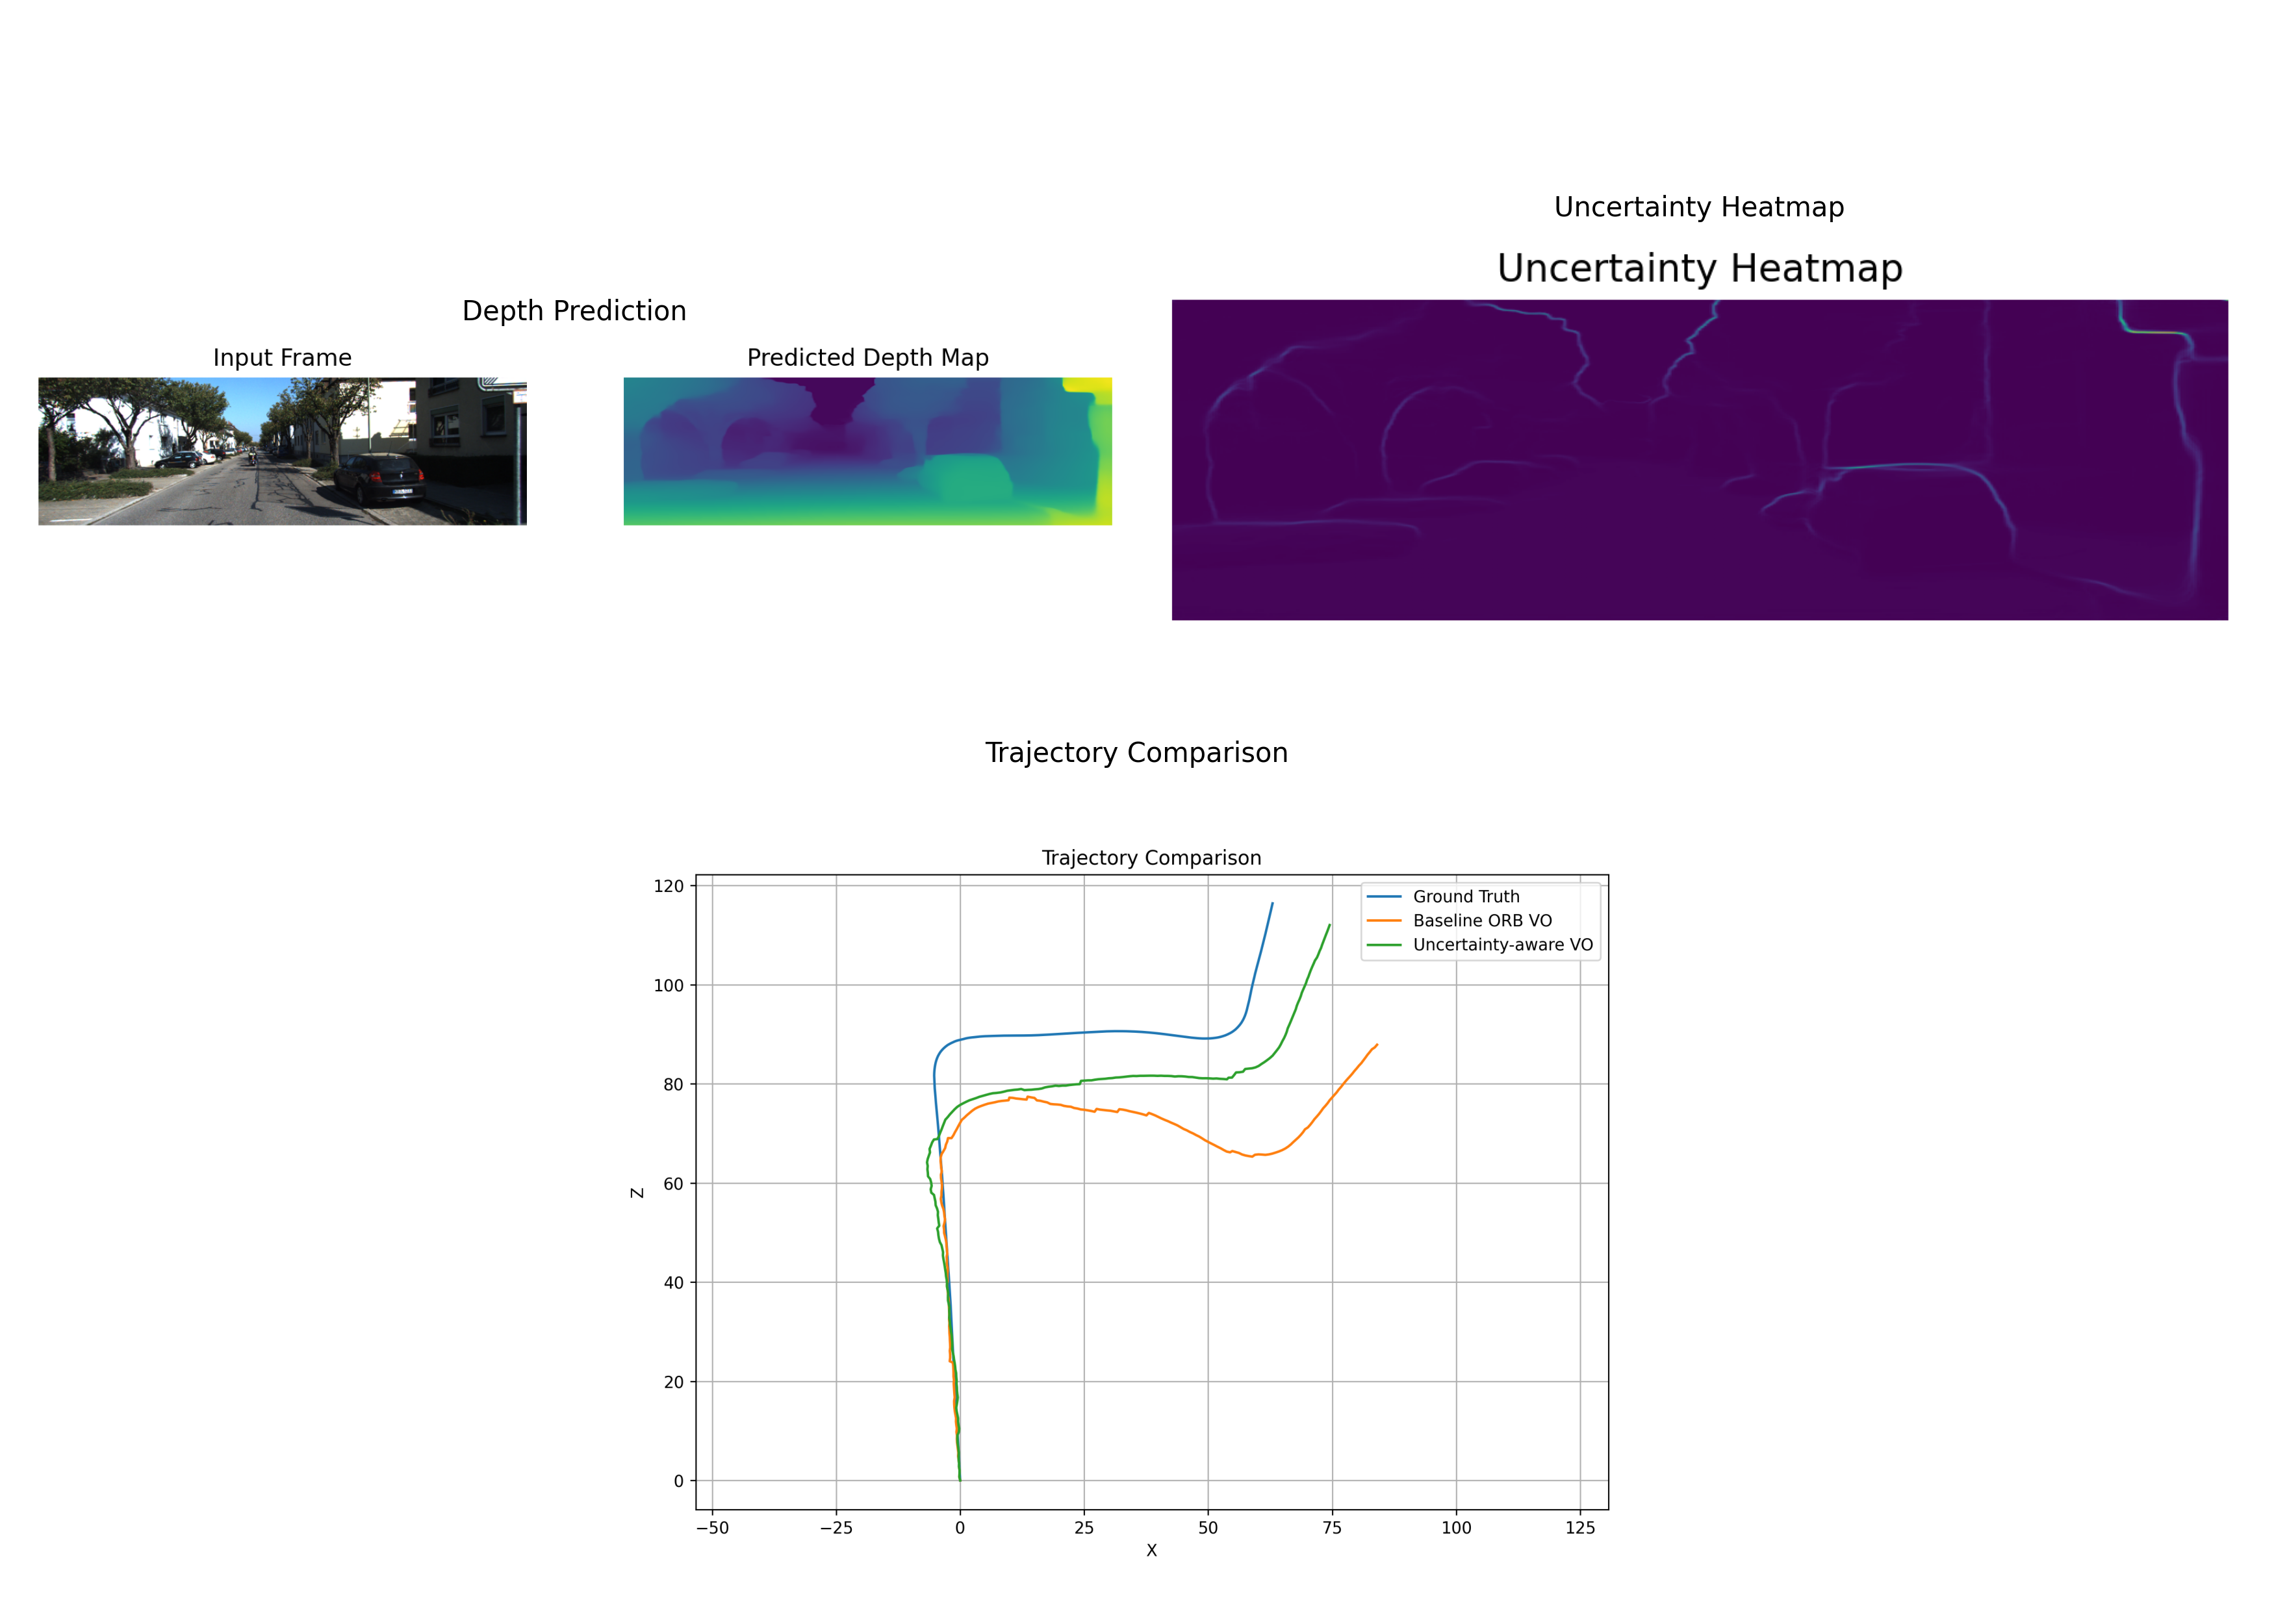

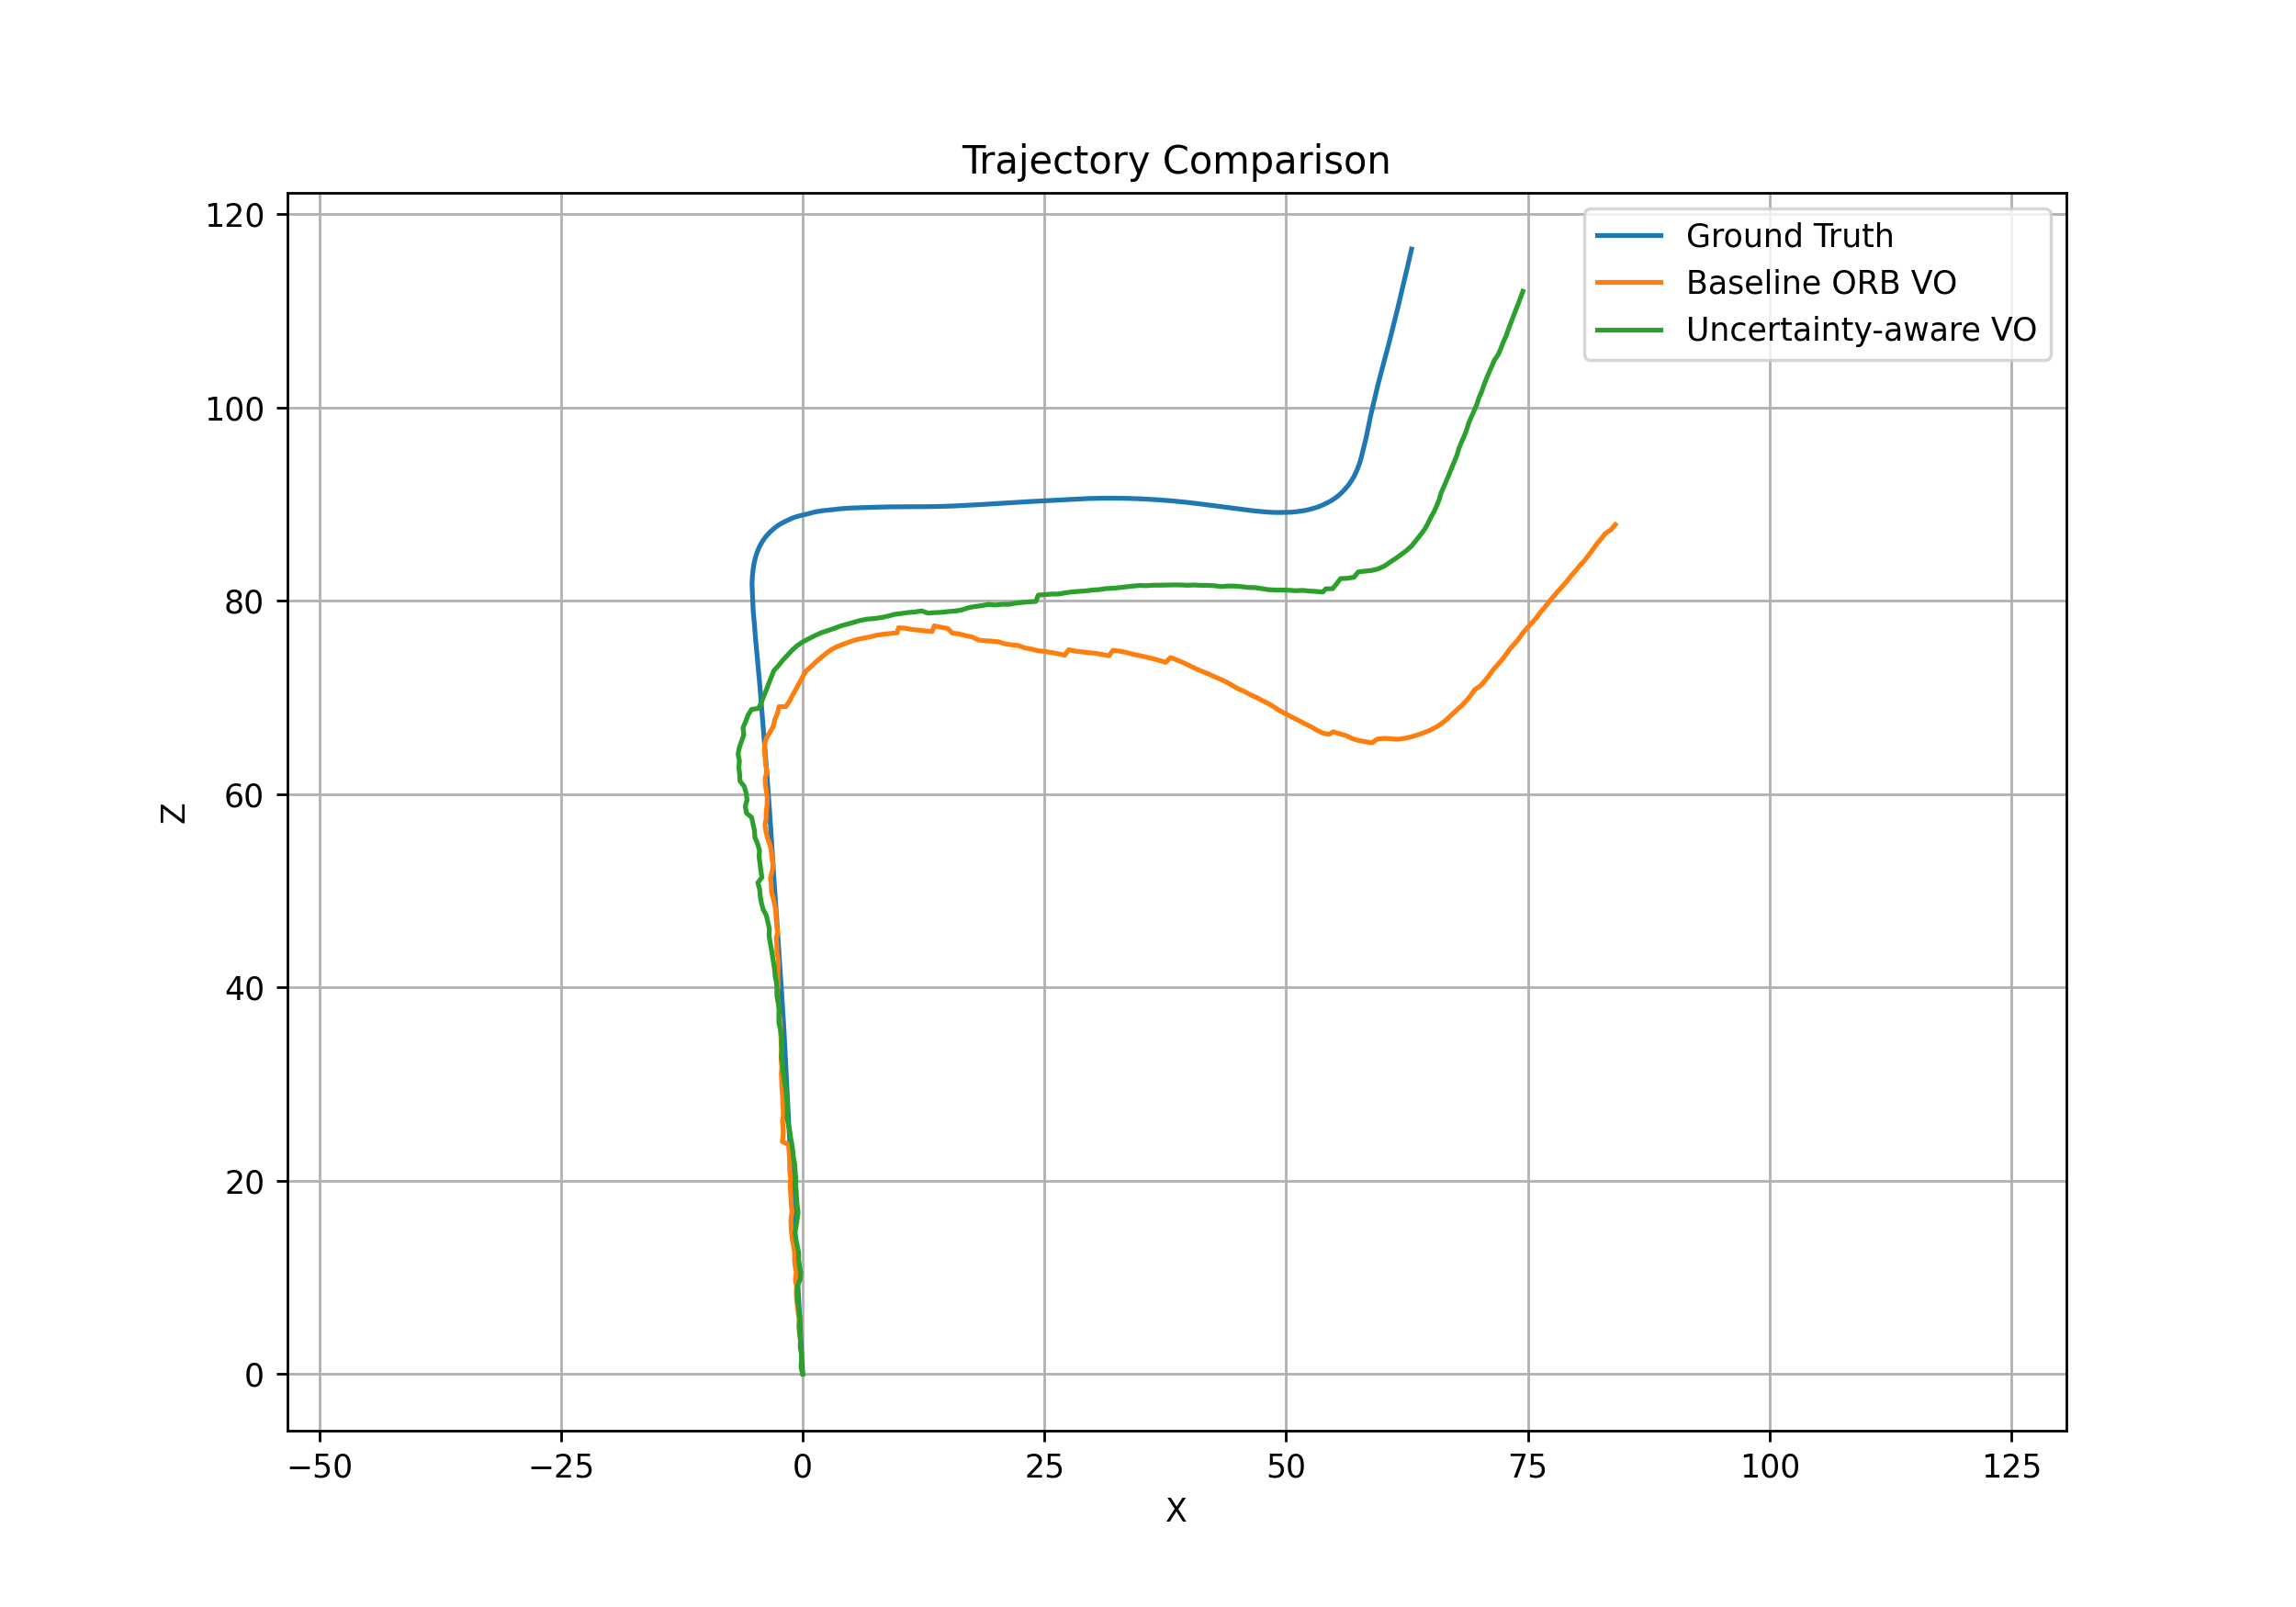

D3VO-Inspired Uncertainty-Aware Monocular Visual Odometry

Baseline ATE: 13.54803446612973
Filtered ATE: 8.145818778090401
Baseline RPE: 0.27504493407622377
Filtered RPE: 0.21236967091717396
ATE Improvement: 39.87%



In [7]:
from IPython.display import Image, display

display(Image("/kaggle/working/outputs/project_dashboard.png"))
display(Image("/kaggle/working/outputs/trajectory_comparison.png"))

print(open("/kaggle/working/outputs/results.txt").read())